# ESS 배터리 수명 조기 분류
최초 5사이클로 `cycle_life < 550 → 단수명(0)`, `≥550 → 장수명(1)`을 분류한다.
Batch 1은 학습·내부 검증, Batch 2는 최종 평가, Batch 3는 EDA까지만 사용한다.

Day1에서 후보로 지정했던 로지스틱 회귀, RBF SVM, 랜덤 포레스트에 더해 Shrinkage LDA와 Dummy를 비교한다.  
**주의:** Batch 1의 단수명 셀은 1개뿐이라 유효한 이진분류 CV 및 Hold-out 검증이 불가능할 것으로 판단된다.

## 1. 라이브러리와 경로

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from IPython.display import display

# 저장소 루트 또는 code 폴더에서 실행할 수 있도록 프로젝트 경로를 찾습니다.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "code/pipeline.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("DS-Miniproject 폴더에서 노트북을 실행하세요.")
sys.path.insert(0, str(ROOT / "code"))
from pipeline import (FEATURE_SETS, extract_features, data_counts, split_batch1,
                      compare_validation, choose_candidate, evaluate_test, reporting_table)
DATA_DIR = ROOT / "data/rawdata/archive"
RESULTS_DIR = ROOT / "results"


Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/yun/.cache/fontconfig
	/Users/yun/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/yun/.cache/fontconfig
	/Users/yun/.fontconfig


Matplotlib is building the font cache; this may take a moment.


## 2. 최초 5사이클 피처 추출
용량·저항·온도·충전시간 평균, 용량 표준편차,
`Q5(V)-Q4(V)` 로그분산·최솟값, 충전 정책 3개 변수를 추출한다.

Batch 1의 빈 cycle 1을 제거해도 cycle 6을 가져오지 않는다.  
결측 수명을 채우지 않으며 ID·Batch·수명은 입력에서 제외한다.

In [2]:
cells = extract_features(DATA_DIR, batch_names=("batch1", "batch2"))
counts = data_counts(cells)
display(counts)

,total,known,unknown,short,long
batch,,,,,
batch1,46,46,0,1,45
batch2,47,39,8,30,9


## 3. 피처 품질 확인

In [3]:
features = FEATURE_SETS["basic_delta_policy"]
display(cells.groupby("batch")["observed_cycles"].agg(["min", "max"]))
display(cells.groupby("batch")[features].agg(lambda s: s.isna().sum()))
# 상관관계도 학습 Batch 1에서만 확인합니다.
correlation = cells.loc[cells.batch == "batch1", features].corr()
display(correlation.loc[["delta_logvar_5_4", "delta_min_5_4"],
                        ["delta_logvar_5_4", "delta_min_5_4"]])

,min,max
batch,,
batch1,4,4
batch2,5,5


,mean_QD_1_5,std_QD_1_5,mean_IR_1_5,mean_Tavg_1_5,mean_Tmax_1_5,mean_chargetime_1_5,delta_logvar_5_4,delta_min_5_4,C_rate_1,switch_SOC,C_rate_2
batch,,,,,,,,,,,
batch1,0,0,0,0,0,0,0,0,0,0,0
batch2,0,0,7,0,0,0,0,0,17,17,17


,delta_logvar_5_4,delta_min_5_4
delta_logvar_5_4,1.000000,-0.190289
delta_min_5_4,-0.190289,1.000000


## 4. 학습·검증·테스트 분리
충전 정책이 학습/검증에 중복되지 않도록 그룹 Hold-out을 사용한다.  
Batch1이 클래스 불균형으로 단수명이 매우 적어 현재 단수명 셀은 학습에 남기므로 검증은 장수명만 포함한다.  
단수명 Recall과 Balanced Accuracy는 검증에서 계산 불가로 표시한다.  
두 클래스가 모든 CV 분할에 존재할 수 없으면 CV는 실행하지 않는다.  

In [4]:
known = cells.loc[cells.target.notna()].copy()
train = known.loc[known.batch == "batch1"].reset_index(drop=True)
test = known.loc[known.batch == "batch2"].reset_index(drop=True)
fit_idx, valid_idx = split_batch1(train)
valid = train.iloc[valid_idx]
assert set(train.iloc[fit_idx].policy).isdisjoint(set(valid.policy))
assert set(train.cell_id).isdisjoint(set(test.cell_id))
split = pd.concat([
    train.iloc[fit_idx].assign(split="Fit"), valid.assign(split="Valid"),
    test.assign(split="Test")], ignore_index=True)
display(pd.crosstab(split.split, split.target))

target,0,1
split,,
Fit,1,34
Test,30,9
Valid,0,11


## 5. Batch 1에서 후보 모델·피처 조합 비교

결측 보완과 표준화는 `sklearn Pipeline` 내부에서 학습 데이터 기준으로 수행한다.  
클래스 불균형을 고려해 `class_weight`를 적용하지만, Batch 1의 단수명 표본이 1개뿐인 한계는 남는다.

피처는 `기본 / 기본+ΔQ / 기본+로그분산 / 기본+ΔQ+충전정책` 조합으로 비교한다.  
Shrinkage LDA는 소표본과 피처 중복에 대응하기 위한 후보 모델로 포함한다.

In [5]:
comparison = compare_validation(train, fit_idx, valid_idx)
display(comparison.round(4))

/Users/yun/workspace/DS-Miniproject/.venv/lib/python3.11/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/Users/yun/workspace/DS-Miniproject/.venv/lib/python3.11/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(
/Users/yun/workspace/DS-Miniproject/.venv/lib/python3.11/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(


/Users/yun/workspace/DS-Miniproject/.venv/lib/python3.11/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(


,model,features,F1,Accuracy,Macro_F1,Short_Recall,Balanced_Accuracy,CV_F1,CV_Accuracy,CV_Macro_F1,CV_status
0,Dummy,basic,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
1,Logistic,basic,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
2,SVM,basic,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
3,ShrinkageLDA,basic,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
4,RandomForest,basic,0.9524,0.9091,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
5,Dummy,basic_delta,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
6,Logistic,basic_delta,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
7,SVM,basic_delta,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
8,ShrinkageLDA,basic_delta,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
9,RandomForest,basic_delta,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가


## 6. 모델 선택의 근거
후보는 설계 단계에 제한하지 않고 데이터 특성에 맞춰 비교한다.  
유효한 두 클래스 CV와 Hold-out이 가능할 때만 Batch 1 성능으로 선택하는데, 현재는 규제·클래스 가중치를 적용한 해석 가능한 Logistic + basic_delta를 잠정 기준으로 유지한다.  
모델 후보는 Batch 1 내부에서 비교하되, 단수명 검증 표본 부족으로 최적 모델 확정에는 한계가 있고, Batch 2는 최종 test로만 사용한다.

In [6]:
model_name, feature_name, selection_reason = choose_candidate(comparison, valid)
print(model_name, feature_name)
print(selection_reason)

Logistic basic_delta
검증 불충분: 사전 지정 기준 모델(잠정), 최적 모델 확정 불가


## 7. Batch 1 전체 재학습 → Batch 2 최종 평가
후보 모델과 함께 가장 많은 클래스를 반복 예측하는 Dummy 모델을 기준선으로 비교한다.  
최종 평가에서는 Accuracy 외에도 단수명 Recall, Macro F1, Balanced Accuracy를 함께 확인한다.

In [7]:
test_scores, predictions, models = evaluate_test(train, test, feature_name)
display(test_scores.round(4))

/Users/yun/workspace/DS-Miniproject/.venv/lib/python3.11/site-packages/sklearn/covariance/_empirical_covariance.py:100: UserWarning: Only one sample available. You may want to reshape your data array
  warnings.warn(


,model,features,F1,Accuracy,Macro_F1,Short_Recall,Balanced_Accuracy
0,Dummy,basic_delta,0.3750,0.2308,0.1875,0.0000,0.5000
1,Logistic,basic_delta,0.2667,0.1538,0.1333,0.0000,0.3333
2,SVM,basic_delta,0.3750,0.2308,0.1875,0.0000,0.5000
3,ShrinkageLDA,basic_delta,0.2222,0.2821,0.2778,0.2333,0.3389
4,RandomForest,basic_delta,0.3043,0.1795,0.1522,0.0000,0.3889


## 8. 성능표
성능 지표는 0~1 범위로 표시하며, Gap은 두 평가 구간의 성능 차이를 의미한다.  
내부 CV가 불가능한 경우 해당 값은 N/A로 표시한다.  
원논문의 95.1% Accuracy는 참고 기준으로만 제시하며, 본 과제와는 Batch 구성과 전처리·검증 조건이 달라 직접적인 성능 비교에는 한계가 있다.

In [8]:
reporting = reporting_table(comparison, test_scores, model_name, feature_name)
display(reporting.round(4))
print("선정 모델의 Test 상세 지표")
display(test_scores.loc[test_scores.model == model_name].round(4))

,구분,F1-Score,Accuracy,비고
0,Train (Batch 1 CV),NaN,NaN,단수명 표본/정책 그룹 부족으로 계산 불가
1,Valid (Batch 1 Hold-out),1.0000,1.0000,장수명만 포함: 단수명 검증 불가
2,Test (Batch 2),0.2667,0.1538,선택 후 최종 평가
3,Gap (Train-Valid),NaN,NaN,CV 결측으로 Gap 계산 불가
4,Gap (Valid-Test),0.7333,0.8462,클래스 구성도 달라 과적합으로 단정 불가
5,Gap (Target-Test),NaN,0.7972,Target Accuracy 95.1%; F1 목표값은 미제시


선정 모델의 Test 상세 지표


,model,features,F1,Accuracy,Macro_F1,Short_Recall,Balanced_Accuracy
1,Logistic,basic_delta,0.2667,0.1538,0.1333,0.0,0.3333


## 9. 혼동행렬과 오류 분석

              precision    recall  f1-score   support

       short       0.00      0.00      0.00        30
        long       0.17      0.67      0.27         9

    accuracy                           0.15        39
   macro avg       0.08      0.33      0.13        39
weighted avg       0.04      0.15      0.06        39



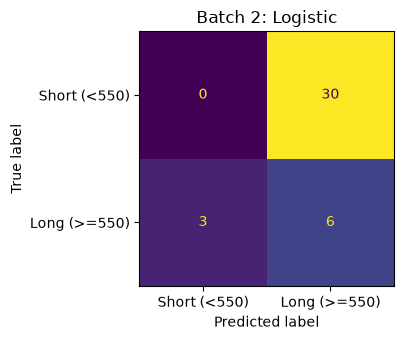

In [9]:
selected = predictions.loc[predictions.model == model_name].copy()
print(classification_report(selected.target.astype(int), selected.prediction,
                            labels=[0, 1], target_names=["short", "long"], zero_division=0))
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(selected.target.astype(int), selected.prediction,
    labels=[0, 1], display_labels=["Short (<550)", "Long (>=550)"], ax=ax, colorbar=False)
ax.set_title(f"Batch 2: {model_name}")
fig.tight_layout()
plt.show()

In [10]:
errors = selected.loc[selected.error].copy()
display(errors[["cell_id", "policy", "cycle_life", "target", "prediction"]])
error_policy = selected.groupby("policy").agg(
    cells=("cell_id", "size"), errors=("error", "sum"), error_rate=("error", "mean"))
display(error_policy.sort_values("error_rate", ascending=False))

,cell_id,policy,cycle_life,target,prediction
39,batch2_cell0,5.2C(58%)-4C,477.0,0,1
40,batch2_cell1,5.6C(26%)-4.5C,491.0,0,1
41,batch2_cell2,5.2C(50%)-4.25C,424.0,0,1
42,batch2_cell3,4.65C(44%)-5C,499.0,0,1
43,batch2_cell4,4.65C(69%)-6C,444.0,0,1
44,batch2_cell5,3.6C(30%)-6C,416.0,0,1
45,batch2_cell6,3.6C(9%)-5C,393.0,0,1
49,batch2_cell10,4.8C(80%)-4.8C,492.0,0,1
50,batch2_cell11,5.2C(50%)-4.25C,449.0,0,1
51,batch2_cell12,4.65C(44%)-5C,466.0,0,1


,cells,errors,error_rate
policy,,,
3.6C(30%)-6C,2,2,1.0
3.6C(9%)-5C,2,2,1.0
4.65C(44%)-5C,2,2,1.0
4.65C(69%)-6C,2,2,1.0
4.8C(80%)-4.8C,5,5,1.0
5.2C(50%)-4.25C,5,5,1.0
5.2C(58%)-4C,4,4,1.0
5.6C(26%)-4.5C,6,6,1.0
6C(60%)-3C,2,2,1.0


## 10. 성능표 저장
각 후보의 Train(CV)·Valid·Test·Gap을 한 CSV로 저장한다.

In [11]:
tables = []
for name in test_scores.model:
    table = reporting_table(comparison, test_scores, name, feature_name)
    table.insert(0, "model", name)
    table.insert(1, "features", feature_name)
    table["final_model"] = name == model_name
    detail = test_scores.loc[test_scores.model == name].iloc[0]
    for metric in ["Macro_F1", "Short_Recall", "Balanced_Accuracy"]:
        table[metric] = float("nan")
        table.loc[table["구분"] == "Test (Batch 2)", metric] = detail[metric]
    tables.append(table)
performance = pd.concat(tables, ignore_index=True)
# 결과 폴더가 없는 새 checkout에서도 저장할 수 있도록 생성합니다.
RESULTS_DIR.mkdir(exist_ok=True)
performance.to_csv(RESULTS_DIR / "model_performance.csv", index=False)
print("저장:", RESULTS_DIR / "model_performance.csv")

저장: /Users/yun/workspace/DS-Miniproject/results/model_performance.csv
